# Importing Libraries

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import confusion_matrix

# Loading dataset and deviding to train and test

In [15]:
# loading fashion-MINST

fashion_minst=keras.datasets.fashion_mnist
(X_train, y_train),(X_test,y_test) = fashion_minst.load_data()

# normalize data
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

# flatting image to vectors for model input
X_train=X_train.reshape(-1,28*28)
X_test=X_test.reshape(-1,28*28)

num_classes=10

# Creating model
- one hidden layer with 100 neurons
- ReLu activation function
- L2 Regularization $\lambda = 0.0001$
- Dropout layer with 0.3 rate
- Output layer with softmax activation funtion


In [19]:
model=keras.Sequential([layers.Dense(100,activation='relu',input_shape=(784,),kernel_regularizer=regularizers.l2(0.0001)),layers.Dropout(0.3),layers.Dense(num_classes,activation='softmax')])

# Compiling model
- adam optimazer

In [20]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# Training model
- 25 epochs
- batch size 128

In [22]:
history = model.fit(X_train, y_train, epochs=25, batch_size=128, validation_data=(X_test, y_test))

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8414 - loss: 0.4692 - val_accuracy: 0.8516 - val_loss: 0.4333
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8552 - loss: 0.4292 - val_accuracy: 0.8568 - val_loss: 0.4240
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8582 - loss: 0.4207 - val_accuracy: 0.8644 - val_loss: 0.4025
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8671 - loss: 0.3943 - val_accuracy: 0.8672 - val_loss: 0.3957
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8684 - loss: 0.3921 - val_accuracy: 0.8649 - val_loss: 0.4033
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8732 - loss: 0.3807 - val_accuracy: 0.8695 - val_loss: 0.3948
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8749 - loss: 0.3782 - val_accuracy: 0.8696 - val_loss: 0.3895
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8763 - loss: 0.3745 - val_accuracy: 0.

# Visualizing data

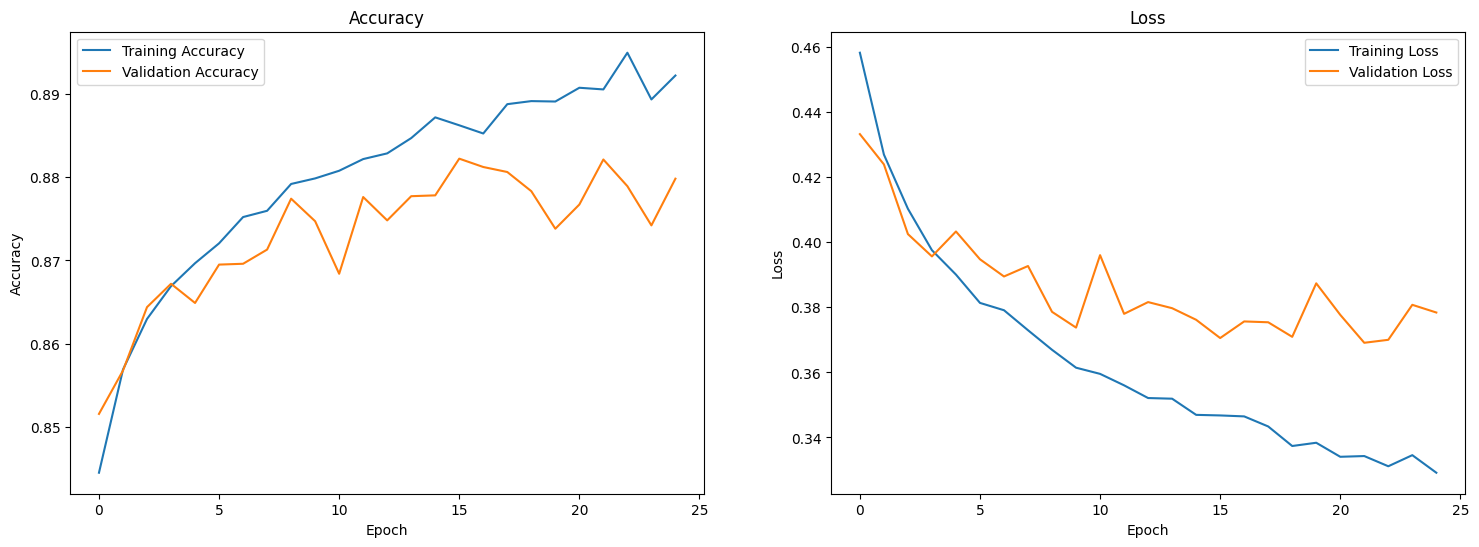

In [24]:
plt.figure(figsize=(18, 6))

# accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


# Evaluate model on test data

In [25]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print('Test accuracy:', test_acc)

# labeling classes
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

Test accuracy: 0.879800021648407
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


# Confusion matrix

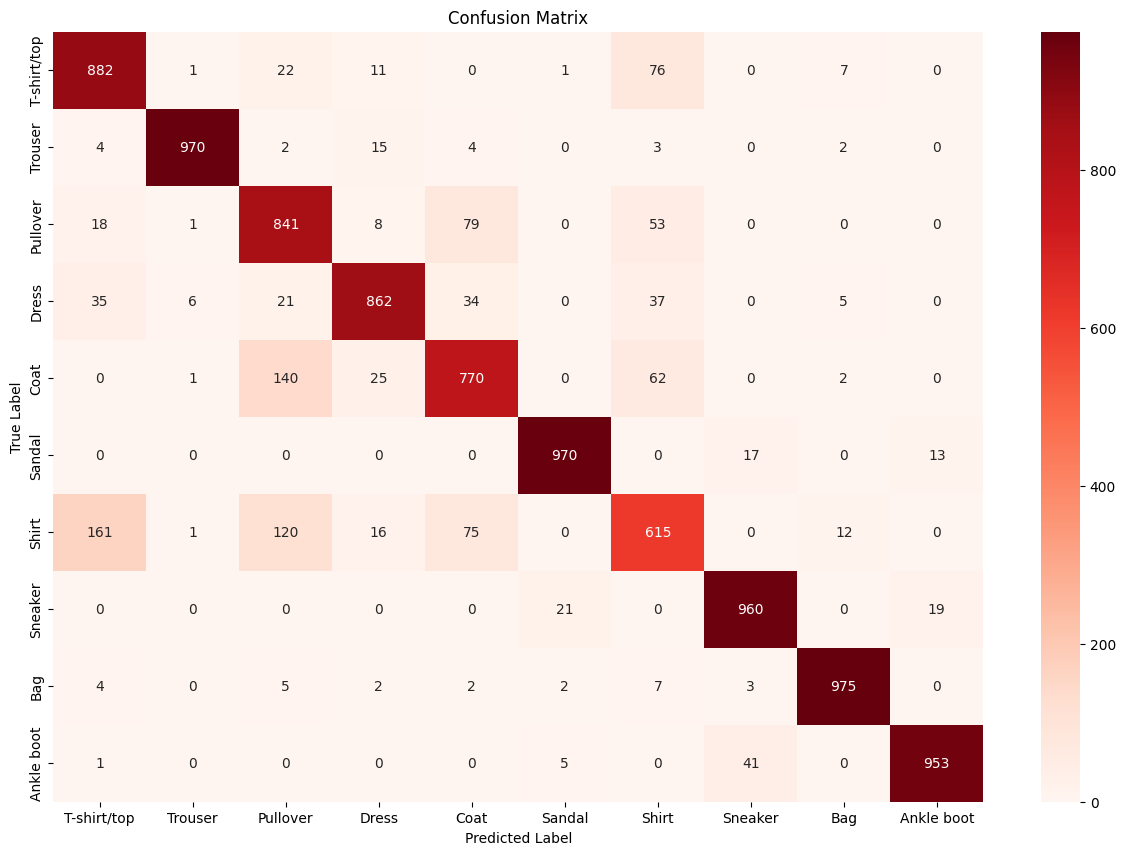

In [30]:
cm = confusion_matrix(y_test, y_pred_classes)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Plot the confusion matrix
plt.figure(figsize=(15, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# frequently confused classes

In [31]:
for i in range(num_classes):
    cm_row = np.copy(cm[i])
    cm_row[i] = 0
    most_confused_class = np.argmax(cm_row)
    print(f"Class '{class_names[i]}' is most frequently confused with class '{class_names[most_confused_class]}'")

Class 'T-shirt/top' is most frequently confused with class 'Shirt'
Class 'Trouser' is most frequently confused with class 'Dress'
Class 'Pullover' is most frequently confused with class 'Coat'
Class 'Dress' is most frequently confused with class 'Shirt'
Class 'Coat' is most frequently confused with class 'Pullover'
Class 'Sandal' is most frequently confused with class 'Sneaker'
Class 'Shirt' is most frequently confused with class 'T-shirt/top'
Class 'Sneaker' is most frequently confused with class 'Sandal'
Class 'Bag' is most frequently confused with class 'Shirt'
Class 'Ankle boot' is most frequently confused with class 'Sneaker'


# How increasing the model complexibility will affect the results?

- Increasing the model complexity by adding more hidden layers or increasing the number of neurons allows the neural network to learn more complex patterns in the data and lead to better results.
-  However, increasing complexity also raises the risk of overfitting, so it's essential to use methods like regularization and dropout solve this problem.



# What criterias are there to find the best configuration of the model?
- Validation performance: this can be seen by visulaizing the results like loss and accuracy plots over epochs.
- Overfitting signs: if there is a significant gap between the validation and training loss or accuracy it means that the model is overfitting on the training data.
- Computational resources: some times we dont have enough power for computinational power needed for the model so we have to find a balance between out computing power and the complexity of our model.
- Hyperparameters: the hyperparameters like learning rate and neurons on each layer and ..  can be tuned by hand or using algorithms like grid search or rnadom search.
- Cross validatoin: using this will give a more relible estimate that the model is having aa good performance or not.
- Evaluation metrics: using metrics like precision, recall and f1-score .. will give us a good sight on the model performance